# 추출 모델 성능 비교 시각화

**담당:** 윤정  
**목적:** koelectra 이진 분류 모델(v2 → v3 → v3.1 → Base) 버전별 성능을 한눈에 비교

## 생성 파일 (docs/img/)
- `01_version_trend.png` — 버전별 F1 추이 (seen / unseen)
- `02_metric_bar.png` — Accuracy / Precision / Recall / F1 종합 막대 비교
- `03_precision_recall_tradeoff.png` — Precision-Recall 트레이드오프 산점도
- `04_seen_vs_unseen_drop.png` — seen → unseen 성능 하락 비교
- `05_radar.png` — 레이더 차트 (v3.1 Small vs Base)
- `06_threshold_curve.png` — Base 모델 threshold 탐색 커브
- `07_data_true_ratio.png` — 학습 데이터 버전별 True 비율 변화

In [1]:
import platform
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 한글 폰트 ────────────────────────────────────────────────────────────────
if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='NanumGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 출력 경로 ────────────────────────────────────────────────────────────────
OUT = Path('..') / 'docs' / 'img'
OUT.mkdir(parents=True, exist_ok=True)
print(f'출력 폴더: {OUT.resolve()}')

# ── 색상 팔레트 ──────────────────────────────────────────────────────────────
C = {
    'v2':    '#9ecae1',
    'v3':    '#4292c6',
    'v3.1':  '#2171b5',
    'base':  '#e6550d',
    'seen':  '#74c476',
    'unseen':'#fd8d3c',
    'gray':  '#969696',
}
print('설정 완료')

출력 폴더: C:\AI-human4\P1\multicultural-ai\model\extraction\docs\img
설정 완료


In [2]:
# ── 셀 1: 성능 데이터 정의 ───────────────────────────────────────────────────
# 출처: eval-model-comparison-2026-05-06.md
#       eval-v3-vs-v3.1-2026-05-06.md
#       eval-base-vs-small-2026-05-07.md
#       Colab eval: base-v1 vs v4_merged on galsan unseen (2026-05-11)
#       labeling-guide.md

# seen = v3.1_val_split (5,650개) / unseen = galsan (5,388개)
MODELS = {
    'v2\n(갈산초\n5,475)': {
        'train_size': 5475,
        'threshold': 0.50,
        'seen':   {'acc': 0.7682, 'f1': 0.3905, 'prec': 0.7362, 'rec': 0.2658},
        'unseen': {'acc': 0.6873, 'f1': 0.3905, 'prec': 0.7362, 'rec': 0.2658},
        'color': C['v2'],
    },
    'v3\n(신규학교\n27,799)': {
        'train_size': 27799,
        'threshold': 0.65,
        'seen':   {'acc': 0.8958, 'f1': 0.8225, 'prec': 0.8149, 'rec': 0.8303},
        'unseen': {'acc': 0.7069, 'f1': 0.4184, 'prec': 0.2836, 'rec': 0.7978},
        'color': C['v3'],
    },
    'v3.1 Small\n(증강\n28,247)': {
        'train_size': 28247,
        'threshold': 0.55,
        'seen':   {'acc': 0.8940, 'f1': 0.8223, 'prec': 0.8025, 'rec': 0.8431},
        'unseen': {'acc': 0.6873, 'f1': 0.4168, 'prec': 0.2765, 'rec': 0.8455},
        'color': C['v3.1'],
    },
    'base-v1\n(v3.1.3\n22,523)': {
        'train_size': 22523,
        'threshold': 0.60,
        'seen':   {'acc': 0.9069, 'f1': 0.8387, 'prec': 0.8459, 'rec': 0.8315},
        'unseen': {'acc': 0.7203, 'f1': 0.4166, 'prec': 0.2875, 'rec': 0.7556},
        'color': C['base'],
    },
    'v4_merged\n(재학습\n47,148)': {
        'train_size': 47148,
        'threshold': 0.70,
        'seen':   None,   # 미측정
        'unseen': {'acc': 0.7400, 'f1': 0.4687, 'prec': 0.3210, 'rec': 0.8680},
        'color': '#d62728',
    },
}

# ── Colab 임계값 탐색 결과 (galsan unseen 5,388개) ───────────────────────────
THR_DATA_V1 = {
    'model': 'base-v1 (v3.1.3)',
    'color': C['base'],
    'thr':  [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    'f1':   [0.4135, 0.4146, 0.4141, 0.4149, 0.4157, 0.4153, 0.4166, 0.4151, 0.4146],
    'prec': [0.2840, 0.2850, 0.2848, 0.2856, 0.2865, 0.2863, 0.2875, 0.2867, 0.2865],
    'rec':  [0.7598, 0.7598, 0.7584, 0.7584, 0.7570, 0.7556, 0.7556, 0.7514, 0.7500],
}
THR_DATA_V4 = {
    'model': 'v4_merged (재학습)',
    'color': '#d62728',
    'thr':  [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    'f1':   [0.4622, 0.4633, 0.4645, 0.4655, 0.4654, 0.4661, 0.4661, 0.4671, 0.4687],
    'prec': [0.3144, 0.3154, 0.3165, 0.3176, 0.3178, 0.3184, 0.3186, 0.3195, 0.3210],
    'rec':  [0.8722, 0.8722, 0.8722, 0.8708, 0.8694, 0.8694, 0.8680, 0.8680, 0.8680],
}

# 기존 seen val split 임계값 탐색 (base-v1 seen, 참고용)
THR_DATA = {
    'thr':  [0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70],
    'f1':   [0.8393, 0.8388, 0.8387, 0.8375, 0.8362, 0.8354, 0.8347],
    'prec': [0.8447, 0.8451, 0.8459, 0.8461, 0.8466, 0.8469, 0.8467],
    'rec':  [0.8339, 0.8327, 0.8315, 0.8291, 0.8260, 0.8242, 0.8230],
}

# 학습 데이터 버전별 True 비율
DATA_VERSIONS = {
    'v2.1\n(갈산초)':       {'size': 5475,  'true_ratio': 0.220},
    'v3\n(신규학교)':        {'size': 27799, 'true_ratio': 0.291},
    'v3.1\n(증강)':         {'size': 28247, 'true_ratio': 0.291},
    'v3.1.3\n(B그룹 제외)': {'size': 22523, 'true_ratio': 0.162},
    'v4_merged\n(재학습용)': {'size': 47148, 'true_ratio': 0.262},
}

model_keys = list(MODELS.keys())
print('데이터 로드 완료')
print(f'모델 수: {len(MODELS)}')

데이터 로드 완료
모델 수: 5


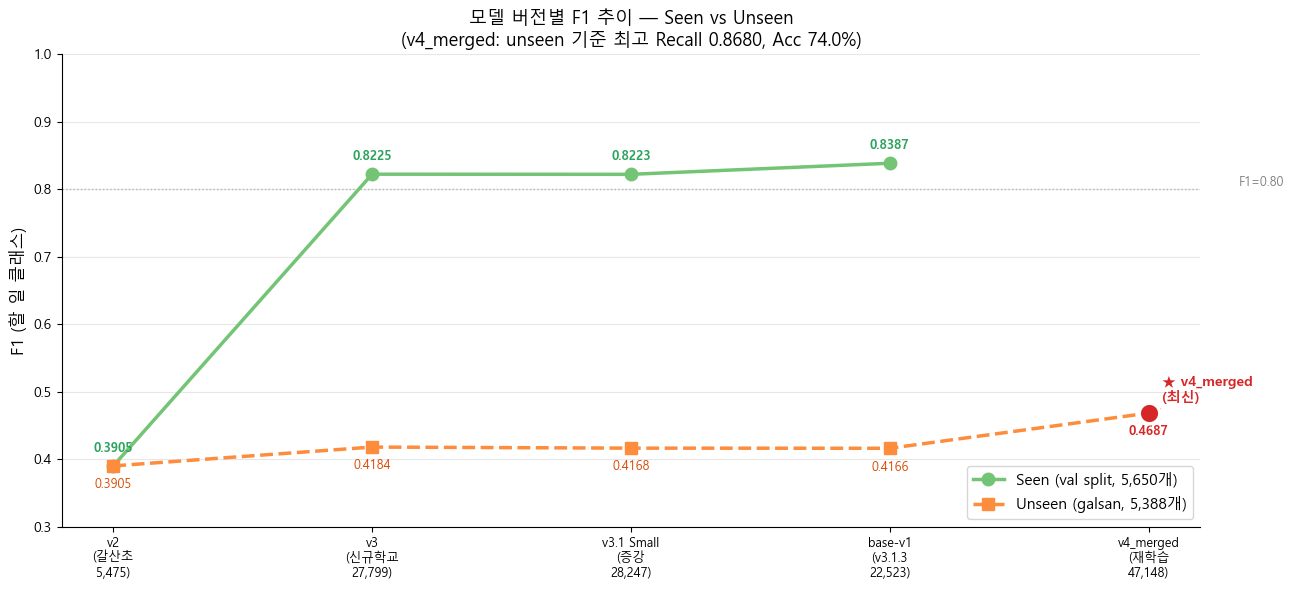

저장: ..\docs\img\01_version_trend.png


In [3]:
# ── 셀 2: [그래프 1] 버전별 F1 추이 (seen / unseen) ─────────────────────────
# v4_merged는 seen 미측정 → unseen 라인에만 포함

seen_keys   = [k for k in model_keys if MODELS[k]['seen'] is not None]
unseen_keys = model_keys  # v4_merged 포함

seen_x   = np.arange(len(seen_keys))
unseen_x = np.arange(len(unseen_keys))

seen_f1s   = [MODELS[k]['seen']['f1']   for k in seen_keys]
unseen_f1s = [MODELS[k]['unseen']['f1'] for k in unseen_keys]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(seen_x, seen_f1s, 'o-', color=C['seen'], linewidth=2.5, markersize=9,
        label='Seen (val split, 5,650개)', zorder=3)
ax.plot(unseen_x, unseen_f1s, 's--', color=C['unseen'], linewidth=2.5, markersize=9,
        label='Unseen (galsan, 5,388개)', zorder=3)

# v4_merged 강조 (unseen 마지막 점)
last_u = len(unseen_keys) - 1
ax.scatter(last_u, unseen_f1s[last_u], s=220, color='#d62728',
           zorder=6, edgecolors='white', linewidth=2.5)
ax.annotate('★ v4_merged\n(최신)', (last_u, unseen_f1s[last_u]),
            textcoords='offset points', xytext=(10, 8),
            fontsize=10, color='#d62728', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.2))

# 수치 레이블
for i, (s, u) in enumerate(zip(seen_f1s, unseen_f1s)):
    ax.annotate(f'{s:.4f}', (i, s), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9, color='#2ca25f', fontweight='bold')
    ax.annotate(f'{u:.4f}', (i, u), textcoords='offset points',
                xytext=(0, -16), ha='center', fontsize=9, color='#d94801')
# v4_merged unseen 수치
ax.annotate(f'{unseen_f1s[last_u]:.4f}', (last_u, unseen_f1s[last_u]),
            textcoords='offset points', xytext=(0, -16),
            ha='center', fontsize=9, color='#d62728', fontweight='bold')

ax.set_xticks(unseen_x)
ax.set_xticklabels([k for k in unseen_keys], fontsize=9)
ax.set_ylim(0.3, 1.0)
ax.set_ylabel('F1 (할 일 클래스)', fontsize=12)
ax.set_title('모델 버전별 F1 추이 — Seen vs Unseen\n(v4_merged: unseen 기준 최고 Recall 0.8680, Acc 74.0%)', fontsize=13)
ax.legend(fontsize=11, loc='lower right')
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.5, linewidth=1)
ax.text(len(unseen_keys) - 0.65, 0.805, 'F1=0.80', color='gray', fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = OUT / '01_version_trend.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

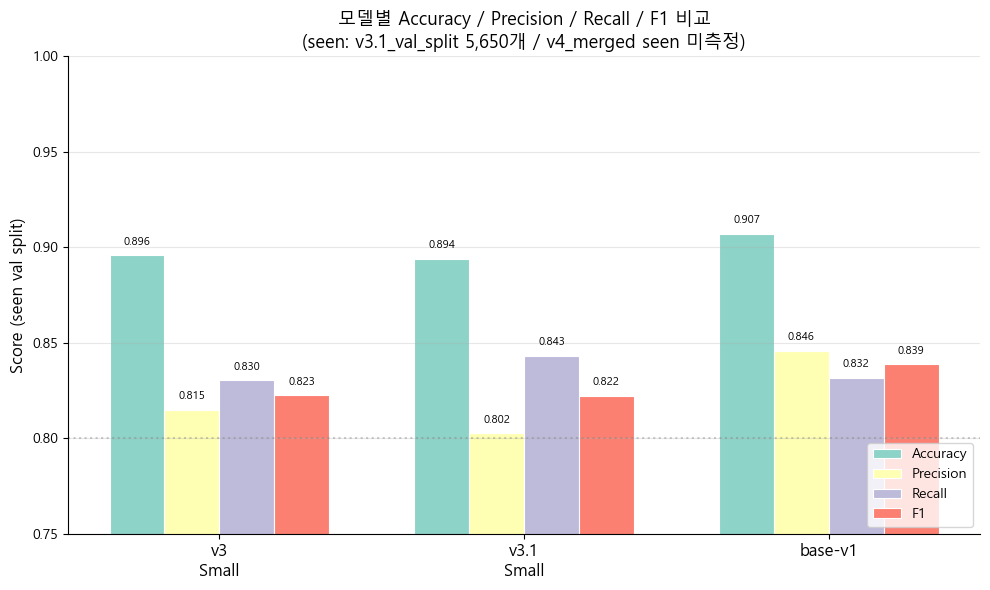

저장: ..\docs\img\02_metric_bar.png


In [4]:
# ── 셀 3: [그래프 2] Accuracy / Precision / Recall / F1 종합 막대 ─────────
# seen 데이터 있는 모델만 (v3 / v3.1 / base-v1)  ※ v4_merged seen 미측정

compare_models = {
    'v3\nSmall':   MODELS['v3\n(신규학교\n27,799)'],
    'v3.1\nSmall': MODELS['v3.1 Small\n(증강\n28,247)'],
    'base-v1':     MODELS['base-v1\n(v3.1.3\n22,523)'],
}
metrics      = ['acc', 'prec', 'rec', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
m_colors     = ['#8dd3c7', '#ffffb3', '#bebada', '#fb8072']

x = np.arange(len(compare_models))
w = 0.18
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

fig, ax = plt.subplots(figsize=(10, 6))

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, m_colors)):
    vals = [m['seen'][metric] for m in compare_models.values()]
    bars = ax.bar(x + offsets[i], vals, w, label=label,
                  color=color, edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(list(compare_models.keys()), fontsize=12)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score (seen val split)', fontsize=12)
ax.set_title('모델별 Accuracy / Precision / Recall / F1 비교\n(seen: v3.1_val_split 5,650개 / v4_merged seen 미측정)', fontsize=13)
ax.legend(fontsize=10, loc='lower right')
ax.axhline(0.8, color='gray', linestyle=':', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = OUT / '02_metric_bar.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

TypeError: 'NoneType' object is not subscriptable

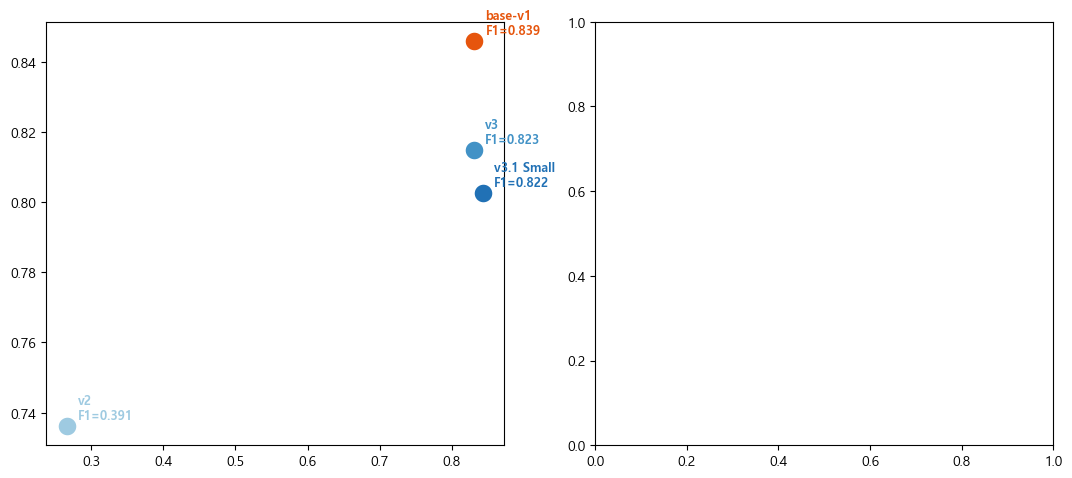

In [5]:
# ── 셀 4: [그래프 3] Precision-Recall 트레이드오프 ───────────────────────────
# 이진 분류에서 Precision vs Recall 균형 — 학부모 서비스 관점

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for ax, split_key, title_suffix in [
    (axes[0], 'seen',   'Seen (val split)'),
    (axes[1], 'unseen', 'Unseen (galsan)'),
]:
    for name, data in MODELS.items():
        p = data[split_key]['prec']
        r = data[split_key]['rec']
        f = data[split_key]['f1']
        short = name.split('\n')[0]
        ax.scatter(r, p, s=200, color=data['color'], zorder=5,
                   edgecolors='white', linewidth=1.5)
        ax.annotate(f'{short}\nF1={f:.3f}',
                    (r, p), textcoords='offset points',
                    xytext=(8, 5), fontsize=9, color=data['color'], fontweight='bold')

    # F1 등고선
    r_range = np.linspace(0.01, 1.0, 200)
    for f1_val, ls in [(0.5, ':'), (0.6, '--'), (0.7, '-.'), (0.8, '-')]:
        p_range = f1_val * r_range / (2 * r_range - f1_val)
        mask = (p_range > 0) & (p_range <= 1)
        ax.plot(r_range[mask], p_range[mask], ls, color='lightgray',
                linewidth=0.8, alpha=0.7)
        idx = np.where(mask)[0]
        if len(idx) > 10:
            ax.text(r_range[idx[-8]], p_range[idx[-8]], f'F1={f1_val}',
                    fontsize=7, color='#aaa', va='center')

    ax.set_xlim(0.1, 1.05)
    ax.set_ylim(0.1, 1.05)
    ax.set_xlabel('Recall (할 일 탐지율)', fontsize=11)
    ax.set_ylabel('Precision (오탐 없는 비율)', fontsize=11)
    ax.set_title(f'Precision-Recall 트레이드오프\n({title_suffix})', fontsize=12)
    ax.grid(alpha=0.2)
    ax.spines[['top', 'right']].set_visible(False)

    # 학부모 서비스 관점 주석
    ax.text(0.13, 0.97, '← Recall↑: 놓치는 할 일 ↓\n   Precision↓: 노이즈 포함 ↑',
            fontsize=8, color='#555', va='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('모델별 Precision-Recall 트레이드오프', fontsize=14, y=1.01)
plt.tight_layout()
out = OUT / '03_precision_recall_tradeoff.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 5: [그래프 4] Seen → Unseen 성능 하락 비교 ───────────────────────────

target_models = ['v3\n(신규학교\n27,799)', 'v3.1 Small\n(증강\n28,247)',
                 'base-v1\n(v3.1.3\n22,523)']
short_labels  = ['v3 Small', 'v3.1 Small', 'base-v1']
colors_target = [C['v3'], C['v3.1'], C['base']]

seen_f1_t   = [MODELS[k]['seen']['f1']   for k in target_models]
unseen_f1_t = [MODELS[k]['unseen']['f1'] for k in target_models]
drops       = [s - u for s, u in zip(seen_f1_t, unseen_f1_t)]

x = np.arange(len(target_models))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5),
                         gridspec_kw={'width_ratios': [2, 1]})

# 왼쪽: seen vs unseen
ax = axes[0]
bars1 = ax.bar(x - w/2, seen_f1_t,   w, label='Seen (val split)',
               color=C['seen'],   edgecolor='white')
bars2 = ax.bar(x + w/2, unseen_f1_t, w, label='Unseen (galsan)',
               color=C['unseen'], edgecolor='white')
for bar, val in zip(bars1, seen_f1_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, val in zip(bars2, unseen_f1_t):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=12)
ax.set_ylim(0.35, 0.96)
ax.set_ylabel('F1 (할 일)', fontsize=12)
ax.set_title('Seen vs Unseen F1 비교', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

# 오른쪽: drop 크기
ax2 = axes[1]
drop_bars = ax2.bar(x, drops, color=colors_target,
                    edgecolor='white', width=0.5)
for bar, d in zip(drop_bars, drops):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{d:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(short_labels, fontsize=12)
ax2.set_ylim(0, 0.55)
ax2.set_ylabel('F1 하락폭 (seen - unseen)', fontsize=11)
ax2.set_title('일반화 격차\n(낮을수록 좋음)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top', 'right']].set_visible(False)

best_idx = int(np.argmin(drops))
ax2.annotate('최소 격차',
             xy=(best_idx, drops[best_idx]),
             xytext=(best_idx + 0.35, drops[best_idx] + 0.06),
             arrowprops=dict(arrowstyle='->', color='green'),
             fontsize=10, color='green', fontweight='bold')

plt.suptitle('Seen → Unseen 성능 하락 비교 (일반화 능력)', fontsize=14, y=1.01)
plt.tight_layout()
out = OUT / '04_seen_vs_unseen_drop.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 6: [그래프 5] 레이더 차트 (v3.1 Small vs base-v1) ────────────────────

radar_metrics = ['Accuracy', 'F1', 'Precision', 'Recall']
n = len(radar_metrics)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
angles += angles[:1]

v31_seen   = [MODELS['v3.1 Small\n(증강\n28,247)']['seen'][k]
              for k in ['acc', 'f1', 'prec', 'rec']]
base_seen  = [MODELS['base-v1\n(v3.1.3\n22,523)']['seen'][k]
              for k in ['acc', 'f1', 'prec', 'rec']]
v31_unseen = [MODELS['v3.1 Small\n(증강\n28,247)']['unseen'][k]
              for k in ['acc', 'f1', 'prec', 'rec']]
base_unseen = [MODELS['base-v1\n(v3.1.3\n22,523)']['unseen'][k]
               for k in ['acc', 'f1', 'prec', 'rec']]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), subplot_kw=dict(polar=True))

for ax, data_pairs, title in [
    (axes[0],
     [(v31_seen,   C['v3.1'], 'v3.1 Small'),
      (base_seen,  C['base'], 'base-v1')],
     'Seen (val split)'),
    (axes[1],
     [(v31_unseen,  C['v3.1'], 'v3.1 Small'),
      (base_unseen, C['base'], 'base-v1')],
     'Unseen (galsan)'),
]:
    for vals, color, label in data_pairs:
        plot_vals = vals + vals[:1]
        f1_val = vals[1]
        ax.plot(angles, plot_vals, 'o-', linewidth=2, color=color,
                label=f'{label} (F1={f1_val:.4f})')
        ax.fill(angles, plot_vals, alpha=0.12, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, fontsize=12)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
    ax.set_title(title, fontsize=12, pad=18)
    ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.15), fontsize=10)
    ax.grid(color='gray', alpha=0.3)

plt.suptitle('v3.1 Small vs base-v1 — 4개 지표 레이더 차트', fontsize=14, y=1.02)
plt.tight_layout()
out = OUT / '05_radar.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 7: [그래프 6] Base 모델 Threshold 탐색 커브 ─────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(THR_DATA['thr'], THR_DATA['f1'],   'o-', color='#e6550d', linewidth=2.5,
        markersize=8, label='F1', zorder=5)
ax.plot(THR_DATA['thr'], THR_DATA['prec'], 's--', color='#3182bd', linewidth=2,
        markersize=7, label='Precision')
ax.plot(THR_DATA['thr'], THR_DATA['rec'],  '^-.', color='#31a354', linewidth=2,
        markersize=7, label='Recall')

# 최적 threshold 표시
best_thr = THR_DATA['thr'][np.argmax(THR_DATA['f1'])]
best_f1  = max(THR_DATA['f1'])
ax.axvline(best_thr, color='#e6550d', linestyle=':', alpha=0.7, linewidth=1.5)
ax.annotate(f'최적 threshold={best_thr}\nF1={best_f1:.4f}',
            xy=(best_thr, best_f1),
            xytext=(best_thr + 0.03, best_f1 - 0.004),
            arrowprops=dict(arrowstyle='->', color='#e6550d', lw=1.5),
            fontsize=10, color='#e6550d', fontweight='bold')

for thr, f1_val in zip(THR_DATA['thr'], THR_DATA['f1']):
    ax.text(thr, f1_val + 0.0005, f'{f1_val:.4f}', ha='center',
            va='bottom', fontsize=8, color='#e6550d')

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.815, 0.860)
ax.set_xticks(THR_DATA['thr'])
ax.set_title('Base 모델 Threshold 탐색\n(곡선이 평탄 — 모델이 양 끝으로 명확히 분리하는 증거)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
out = OUT / '06_threshold_curve.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 8: [그래프 7] 학습 데이터 버전별 True 비율 + 크기 변화 ────────────────

dv_keys   = list(DATA_VERSIONS.keys())
dv_sizes  = [DATA_VERSIONS[k]['size']       for k in dv_keys]
dv_ratios = [DATA_VERSIONS[k]['true_ratio'] for k in dv_keys]
dv_colors = [C['v3'], C['v3'], C['v3.1'], C['base'], C['unseen']]

fig, ax1 = plt.subplots(figsize=(11, 5.5))
ax2 = ax1.twinx()

x = np.arange(len(dv_keys))
bars = ax1.bar(x, dv_sizes, color=dv_colors, alpha=0.35, edgecolor='white', width=0.5)
line, = ax2.plot(x, [r * 100 for r in dv_ratios], 'o-', color='#e6550d',
                 linewidth=2.5, markersize=9, label='True 비율 (%)', zorder=5)

for i, (size, ratio) in enumerate(zip(dv_sizes, dv_ratios)):
    ax1.text(i, size + 400, f'{size:,}', ha='center', va='bottom', fontsize=9, color='#444')
    ax2.text(i, ratio * 100 + 0.8, f'{ratio*100:.1f}%', ha='center', va='bottom',
             fontsize=10, color='#e6550d', fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(dv_keys, fontsize=10)
ax1.set_ylabel('학습 데이터 총 문장 수', fontsize=12, color='#555')
ax2.set_ylabel('is_todo=True 비율 (%)', fontsize=12, color='#e6550d')
ax2.tick_params(axis='y', colors='#e6550d')
ax2.set_ylim(0, 40)
ax1.set_ylim(0, 58000)

ax1.set_title('학습 데이터 버전별 크기 및 True 비율 변화\n(v4_merged: True 비율 의도적 상향 — 현재 모델의 recall 보정 목적)', fontsize=13)

bar_patch = mpatches.Patch(color='#9ecae1', alpha=0.5, label='데이터 크기 (막대)')
ax1.legend(handles=[bar_patch, line], fontsize=10, loc='upper left')
ax1.grid(axis='y', alpha=0.2)
ax1.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)

plt.tight_layout()
out = OUT / '07_data_true_ratio.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 9: 최종 요약 출력 ────────────────────────────────────────────────────

print('=' * 65)
print('  추출 모델 성능 비교 요약')
print('=' * 65)
print(f'{"모델":<22} {"Acc":>7} {"F1":>7} {"Prec":>7} {"Rec":>7}  (seen)')
print('-' * 65)
for name, data in MODELS.items():
    s = data['seen']
    short = name.replace('\n', ' ')
    print(f'{short:<22} {s["acc"]:>7.4f} {s["f1"]:>7.4f} {s["prec"]:>7.4f} {s["rec"]:>7.4f}')

print()
print(f'{"모델":<22} {"Acc":>7} {"F1":>7} {"Prec":>7} {"Rec":>7}  (unseen / galsan)')
print('-' * 65)
for name, data in MODELS.items():
    u = data['unseen']
    short = name.replace('\n', ' ')
    print(f'{short:<22} {u["acc"]:>7.4f} {u["f1"]:>7.4f} {u["prec"]:>7.4f} {u["rec"]:>7.4f}')

print('=' * 65)
print('  생성된 그래프')
print('=' * 65)
for p in sorted(OUT.glob('*.png')):
    print(f'  {p.name}')

In [ ]:
# ── 셀 10: [핵심 그래프] base-v1 → v4_merged 성능 향상 ──────────────────────
# PPT 1장용 — 재학습 효과를 한눈에

from matplotlib.lines import Line2D

V1_BEST = {'Accuracy': 0.7203, 'F1': 0.4166, 'Precision': 0.2875, 'Recall': 0.7556}
V4_BEST = {'Accuracy': 0.7400, 'F1': 0.4687, 'Precision': 0.3210, 'Recall': 0.8680}
DELTAS  = {k: V4_BEST[k] - V1_BEST[k] for k in V1_BEST}

COLOR_V1 = '#2171b5'
COLOR_V4 = '#d62728'

metrics = list(V1_BEST.keys())
y_pos   = np.arange(len(metrics))[::-1]   # 위: Accuracy, 아래: Recall

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={'width_ratios': [2.8, 1.0]})

# ── 왼쪽: 덤벨 차트 ──────────────────────────────────────────────────────────
ax = axes[0]
for metric, yi in zip(metrics, y_pos):
    v1, v4, delta = V1_BEST[metric], V4_BEST[metric], DELTAS[metric]

    # 연결 트랙
    ax.plot([v1, v4], [yi, yi], color='#e0e0e0', linewidth=12,
            solid_capstyle='round', zorder=1)
    # 이전 값 (파란 점)
    ax.scatter(v1, yi, s=320, color=COLOR_V1, zorder=5,
               edgecolors='white', linewidth=2.5)
    # 이후 값 (빨간 점)
    ax.scatter(v4, yi, s=320, color=COLOR_V4, zorder=5,
               edgecolors='white', linewidth=2.5)

    # 수치 레이블
    ax.text(v1 - 0.018, yi, f'{v1:.4f}', ha='right', va='center',
            fontsize=12, color=COLOR_V1, fontweight='bold')
    ax.text(v4 + 0.018, yi, f'{v4:.4f}', ha='left', va='center',
            fontsize=12, color=COLOR_V4, fontweight='bold')

    # 향상 폭 뱃지
    sign = '+' if delta >= 0 else ''
    ax.text((v1 + v4) / 2, yi + 0.055,
            f'{sign}{delta:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold',
            color='#2ca25f',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#edf8e9',
                      edgecolor='#74c476', linewidth=1.2))

ax.set_yticks(y_pos)
ax.set_yticklabels(metrics, fontsize=15)
ax.set_xlim(0.18, 1.03)
ax.set_xlabel('Score  (galsan unseen 5,388문장)', fontsize=12)
ax.set_title('base-v1 (v3.1.3)  →  v4_merged 재학습\n4개 지표 전부 향상', fontsize=14)
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_V1,
           markersize=13, label='base-v1 (v3.1.3 학습)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_V4,
           markersize=13, label='v4_merged (재학습, 47,148개)'),
], fontsize=11, loc='lower right')
ax.grid(axis='x', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

# ── 오른쪽: 향상 폭 막대 ──────────────────────────────────────────────────────
ax2 = axes[1]
delta_vals   = [DELTAS[m] for m in metrics]
delta_colors = ['#41ab5d' if d >= 0 else '#fb6a4a' for d in delta_vals]

bars = ax2.barh(y_pos, delta_vals, height=0.48,
                color=delta_colors, edgecolor='white', linewidth=1)
for bar, val in zip(bars, delta_vals):
    sign = '+' if val >= 0 else ''
    ax2.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
             f'{sign}{val:.4f}', va='center', ha='left',
             fontsize=12, fontweight='bold',
             color='#2ca25f' if val >= 0 else '#d62728')

ax2.set_yticks(y_pos)
ax2.set_yticklabels(metrics, fontsize=14)
ax2.set_xlabel('향상 폭', fontsize=12)
ax2.set_title('재학습 후\n향상 폭', fontsize=13)
ax2.axvline(0, color='gray', linewidth=0.8)
ax2.set_xlim(-0.005, max(delta_vals) + 0.035)
ax2.grid(axis='x', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'v4_merged 재학습 효과  ——  4개 지표 전부 향상\n'
    '특히 Recall  +0.1124  →  놓치는 할 일 문장 대폭 감소',
    fontsize=15, fontweight='bold', y=1.03)

plt.tight_layout()
out = OUT / '08_key_result_v4_improvement.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')

In [ ]:
# ── 셀 11: [그래프 9] base-v1 vs v4_merged 임계값별 성능 비교 ─────────────────
# 전 임계값 구간에서 v4_merged가 우수함을 보여줌

thrs = THR_DATA_V1['thr']
metric_cfg = [
    ('f1',   'F1 (할 일)',  0.38, 0.52),
    ('prec', 'Precision',  0.25, 0.38),
    ('rec',  'Recall',     0.70, 0.92),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

for ax, (key, label, ymin, ymax) in zip(axes, metric_cfg):
    v1_vals = THR_DATA_V1[key]
    v4_vals = THR_DATA_V4[key]

    ax.plot(thrs, v1_vals, 'o-', color=COLOR_V1, linewidth=2.5,
            markersize=8, label='base-v1 (v3.1.3)')
    ax.plot(thrs, v4_vals, 's-', color=COLOR_V4, linewidth=2.5,
            markersize=8, label='v4_merged')

    # 향상 구간 채우기
    ax.fill_between(thrs, v1_vals, v4_vals, alpha=0.18, color='#41ab5d',
                    label='향상 구간')

    # 각 모델 최고점 수치 표시
    best_v1_idx = int(np.argmax(v1_vals))
    best_v4_idx = int(np.argmax(v4_vals))
    ax.annotate(f'{v4_vals[best_v4_idx]:.4f}',
                (thrs[best_v4_idx], v4_vals[best_v4_idx]),
                textcoords='offset points', xytext=(0, 9),
                ha='center', fontsize=9, color=COLOR_V4, fontweight='bold')
    ax.annotate(f'{v1_vals[best_v1_idx]:.4f}',
                (thrs[best_v1_idx], v1_vals[best_v1_idx]),
                textcoords='offset points', xytext=(0, -16),
                ha='center', fontsize=9, color=COLOR_V1)

    # 향상 폭 최대값 뱃지
    max_delta = max(v4 - v1 for v1, v4 in zip(v1_vals, v4_vals))
    ax.text(0.97, 0.05, f'max Δ = +{max_delta:.4f}',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=10, fontweight='bold', color='#2ca25f',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#edf8e9',
                      edgecolor='#74c476', linewidth=1))

    ax.set_xlabel('Threshold', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} vs Threshold', fontsize=12)
    ax.set_ylim(ymin, ymax)
    ax.set_xticks(thrs)
    ax.legend(fontsize=9, loc='upper left')
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    'base-v1 vs v4_merged — 임계값별 F1 / Precision / Recall 비교 (galsan unseen)\n'
    '전 구간에서 v4_merged 우수  |  녹색 영역 = 재학습으로 확보한 성능 마진',
    fontsize=13, y=1.02)

plt.tight_layout()
out = OUT / '09_threshold_comparison_v1_vs_v4.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'저장: {out}')